## Socio Correlation with total crime counts

High School Completion (%) vs Drug Offences

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.21
P-value: 0.273


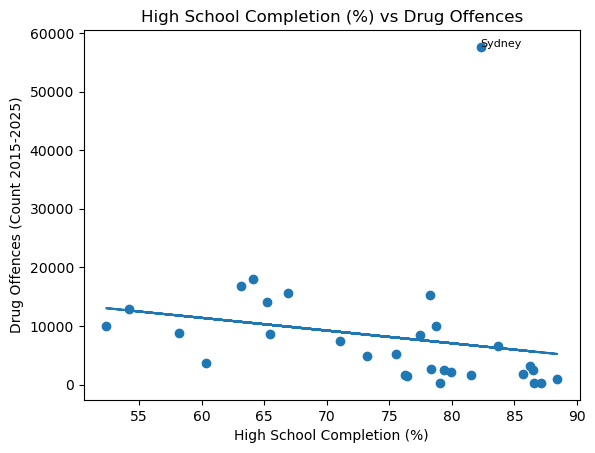




High School Completion (%) vs Violent Crime

Pearson Correlation Coefficient: -0.54
P-value: 0.002


<Figure size 640x480 with 0 Axes>

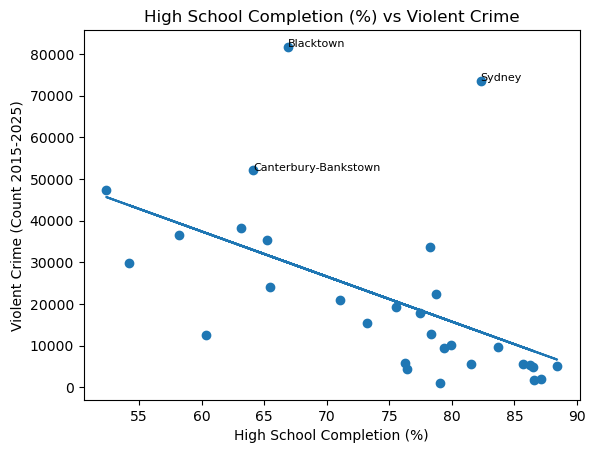




High School Completion (%) vs Property Offences

Pearson Correlation Coefficient: -0.47
P-value: 0.008


<Figure size 640x480 with 0 Axes>

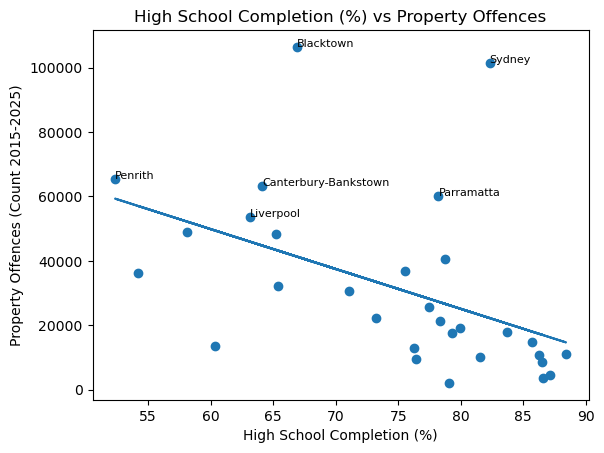




Unemployment (%) vs Drug Offences

Pearson Correlation Coefficient: 0.36
P-value: 0.049


<Figure size 640x480 with 0 Axes>

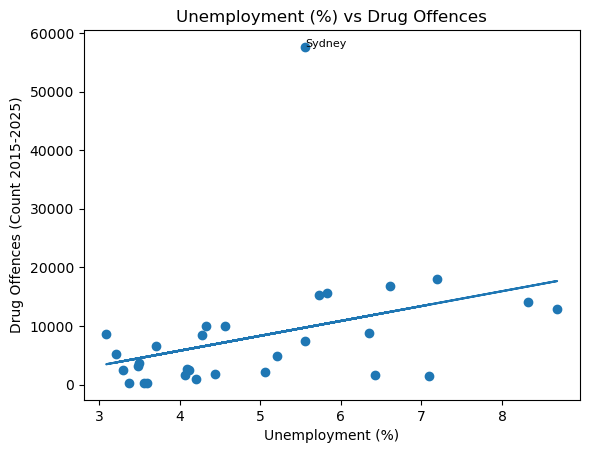




Unemployment (%) vs Violent Crime

Pearson Correlation Coefficient: 0.46
P-value: 0.010


<Figure size 640x480 with 0 Axes>

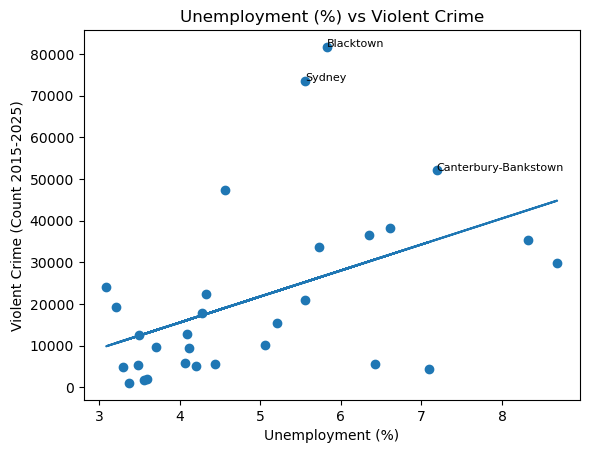




Unemployment (%) vs Property Offences

Pearson Correlation Coefficient: 0.43
P-value: 0.017


<Figure size 640x480 with 0 Axes>

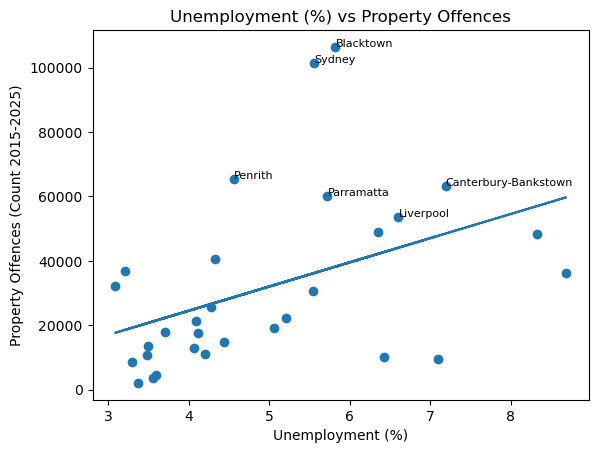




Median Weekly Income ($) vs Drug Offences

Pearson Correlation Coefficient: -0.37
P-value: 0.043


<Figure size 640x480 with 0 Axes>

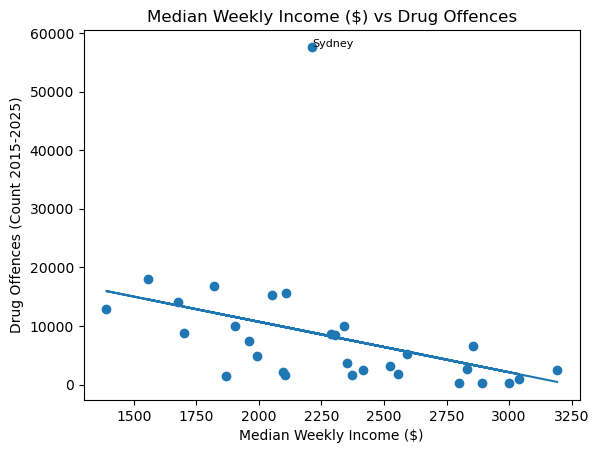




Median Weekly Income ($) vs Violent Crime

Pearson Correlation Coefficient: -0.55
P-value: 0.002


<Figure size 640x480 with 0 Axes>

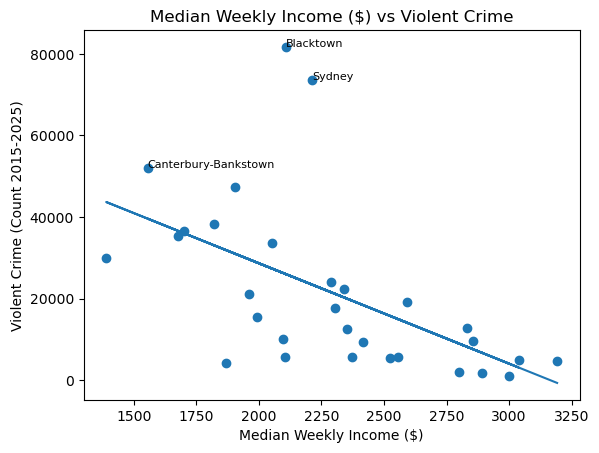




Median Weekly Income ($) vs Property Offences

Pearson Correlation Coefficient: -0.52
P-value: 0.003


<Figure size 640x480 with 0 Axes>

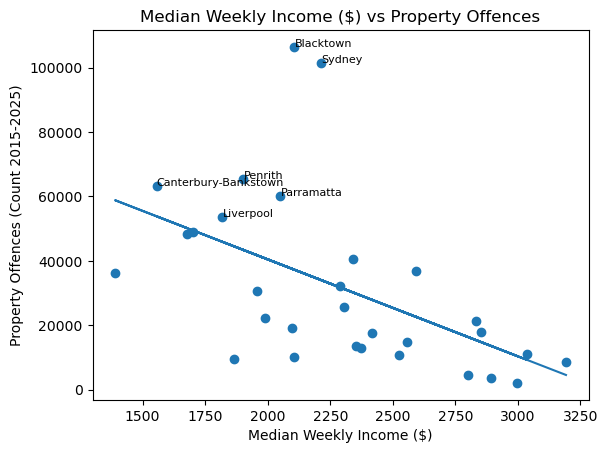




High School Completion (%) vs Drug Offences (Sydney Removed)

Pearson Correlation Coefficient: -0.65
P-value: 0.000


<Figure size 640x480 with 0 Axes>

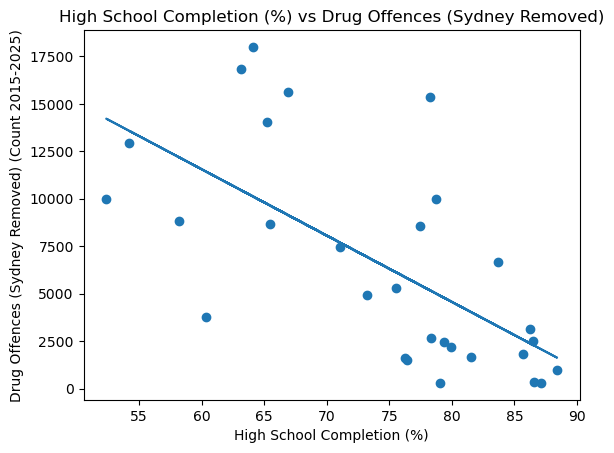




Unemployment (%) vs Drug Offences (Sydney Removed)

Pearson Correlation Coefficient: 0.59
P-value: 0.001


<Figure size 640x480 with 0 Axes>

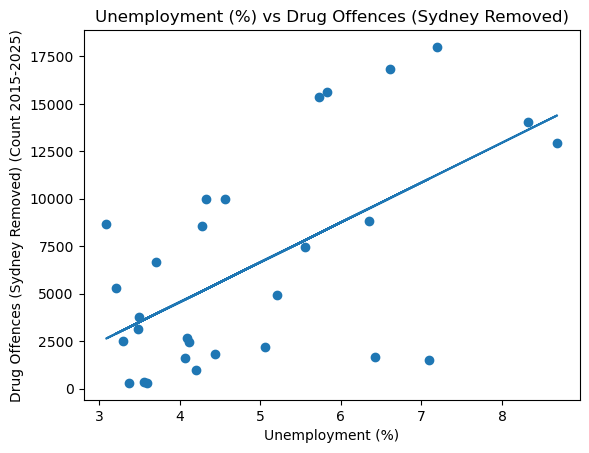




Median Weekly Income ($) vs Drug Offences (Sydney Removed)

Pearson Correlation Coefficient: -0.68
P-value: 0.000


<Figure size 640x480 with 0 Axes>

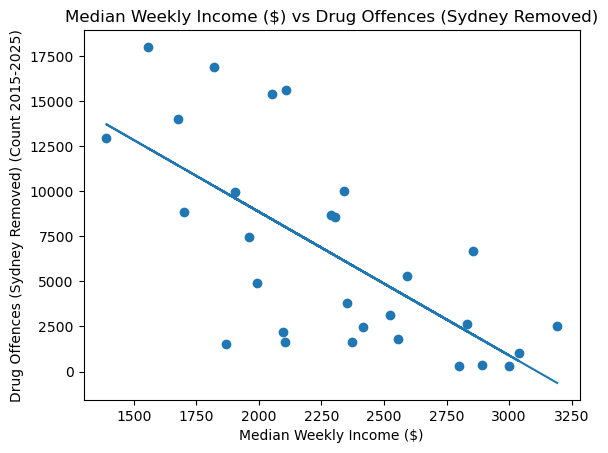

<Figure size 640x480 with 0 Axes>

In [1]:
"""
THE WILD WEST
"""

import numpy as np
from scipy import stats
import geopandas as gpd
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plot

path = Path("/Users/tarapowell/Desktop/GIS AT3") #MOLLY YOU WILL NEED TO ADD YOUR OWN PATH IN


def correlation(x,y):
    pearson = stats.pearsonr(x, y)
    
    p = pearson.pvalue
    r = pearson.statistic
    
    if p > 0.05:
        print("Correlation is not Statistically Signifigant!!!")
    
    print(f"Pearson Correlation Coefficient: {r:.2f}")
    print(f"P-value: {p:.3f}")
    
    return p, r


def printscatter(x,y,xhead,yhead,pointlabels):
    #https://www.statology.org/line-of-best-fit-python/
    m, c = np.polyfit(x, y, 1)

    plot.figure()
    plot.title(f"{xhead} vs {yhead}")
    plot.xlabel(f"{xhead}")
    plot.ylabel(f"{yhead} (Count 2015-2025)")
    plot.scatter(x, y)
    plot.plot(x, m*x+c)
    
    #https://medium.com/@marvelouskgc/three-ways-to-add-labels-to-each-data-point-in-a-scatter-plot-in-python-matplotlib-eugene-tsai-42e4094dc07e
    for i, label in enumerate(pointlabels):
        if y[i] > 50000:
            plot.text(x[i],y[i],label,fontsize=8)
        
    plot.show()
    plot.clf()



#https://medium.com/data-science/how-to-convert-a-shapefile-to-a-dataframe-in-python-a6ca9a893504
inputfile = path / "SydneyLGAs_MGA202056_socioecon_crime_2015_2025.shp"
dataframe = gpd.read_file(inputfile)

pointlabels = dataframe["LGA_NAME25"]

xschool = dataframe["High_Schoo"].to_numpy() #PERCENTAGE High School Completion 
xunemploy = dataframe["Unemployme"].to_numpy() #PERCENTAGE Unemployment
xincome = dataframe["Median_tot"].to_numpy() #Median Weekly Income

xlist = [xschool, xunemploy, xincome]
xheadings = ["High School Completion (%)", "Unemployment (%)", "Median Weekly Income ($)"]

ydrugs = dataframe["Drugs_Tota"].to_numpy()
yVC = dataframe["VC_Total"].to_numpy()
yPO = dataframe["PO_Total"].to_numpy()

ylist = [ydrugs, yVC, yPO]
yheadings = ["Drug Offences", "Violent Crime", "Property Offences"]

#Correlation between total counts and socioeconomic factors. 
for x, xhead in zip(xlist,xheadings):
    for y, yhead in zip(ylist, yheadings):
        print(f"{xhead} vs {yhead}\n")
        correlation(x,y)
        printscatter(x,y,xhead,yhead,pointlabels)
        print("\n\n")
        
#Drug offences has a huge outlier in the Sydney CBD so it will be removed
dataframe_nosyd = dataframe.copy()
dataframe_nosyd = dataframe_nosyd.drop(dataframe_nosyd[dataframe_nosyd["LGA_NAME25"] == "Sydney"].index)

pointlabels_nosyd = dataframe_nosyd["LGA_NAME25"]
ydrugs_nosyd = dataframe_nosyd["Drugs_Tota"].to_numpy()

xschool_nosyd = dataframe_nosyd["High_Schoo"].to_numpy() #PERCENTAGE High School Completion 
xunemploy_nosyd = dataframe_nosyd["Unemployme"].to_numpy() #PERCENTAGE Unemployment
xincome_nosyd = dataframe_nosyd["Median_tot"].to_numpy() #Median Weekly Income

xlist_nosyd = [xschool_nosyd, xunemploy_nosyd, xincome_nosyd]

for x, xhead in zip(xlist_nosyd,xheadings):
    print(f"{xhead} vs Drug Offences (Sydney Removed)\n")
    correlation(x,ydrugs_nosyd)
    printscatter(x,ydrugs_nosyd,xhead, "Drug Offences (Sydney Removed)", pointlabels_nosyd)
    print("\n\n")





## Calculating Change over Time

In [2]:
def graphtime(inputtime, y, yhead, lga):
    time = np.array(inputtime)
    
    m, c = np.polyfit(time, y, 1)
    
    plot.figure()
    plot.title(f"{yhead} count per year for {lga}: 2015 - 2025")
    plot.xlabel("Year")
    plot.ylabel(f"{yhead} (Count)")
    plot.plot(time, y)
    plot.scatter(time, y)
    plot.plot(time, m*time+c)
    plot.show()
    plot.clf()
    
    return m

Pearson Correlation Coefficient: -0.66
P-value: 0.027


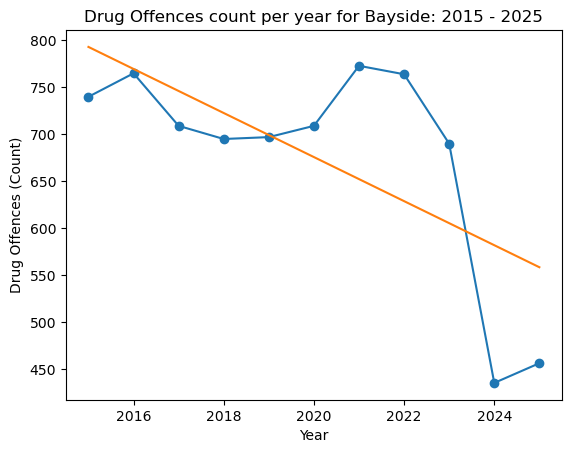

Pearson Correlation Coefficient: 0.74
P-value: 0.009


<Figure size 640x480 with 0 Axes>

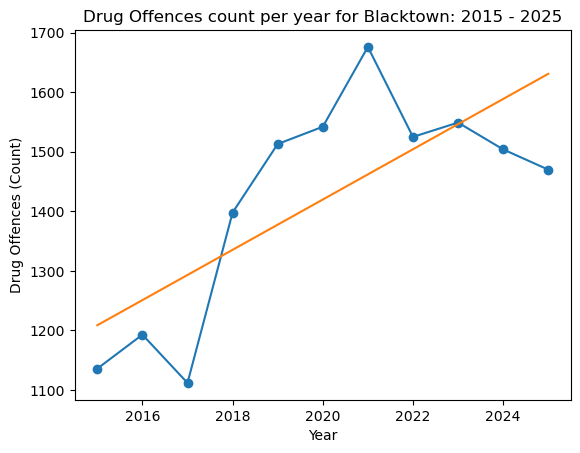

Pearson Correlation Coefficient: 0.62
P-value: 0.040


<Figure size 640x480 with 0 Axes>

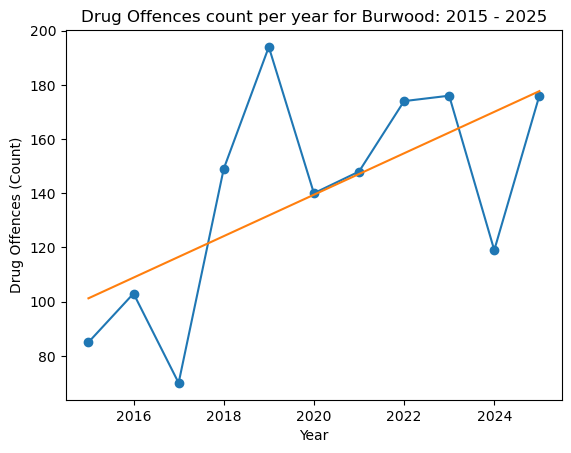

Pearson Correlation Coefficient: -0.88
P-value: 0.000


<Figure size 640x480 with 0 Axes>

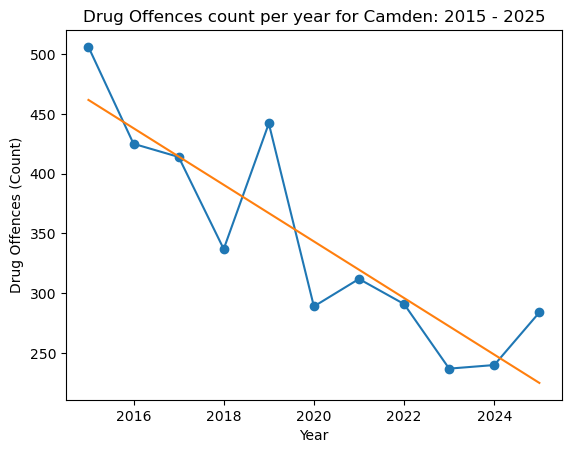

Pearson Correlation Coefficient: -0.81
P-value: 0.003


<Figure size 640x480 with 0 Axes>

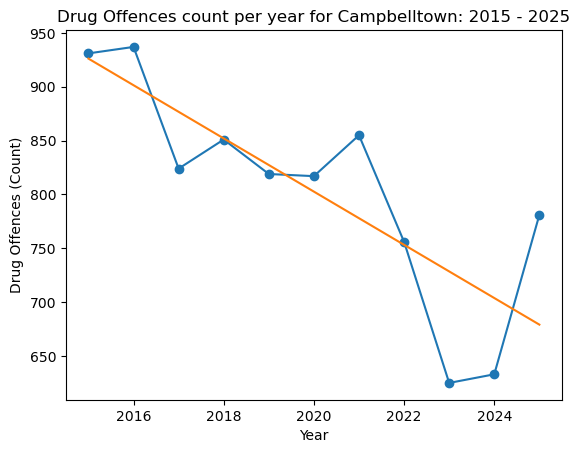

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: 0.53
P-value: 0.093
Correlation for Canada Bay's Drug Offences over time is not Statistically Signifigant

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.13
P-value: 0.697
Correlation for Canterbury-Bankstown's Drug Offences over time is not Statistically Signifigant

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.01
P-value: 0.975
Correlation for Cumberland's Drug Offences over time is not Statistically Signifigant

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.41
P-value: 0.211
Correlation for Fairfield's Drug Offences over time is not Statistically Signifigant

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: 0.59
P-value: 0.056
Correlation for Georges River's Drug Offences over time is not Statistically Signifigant

Correlation is not Statistically Signifigant!

<Figure size 640x480 with 0 Axes>

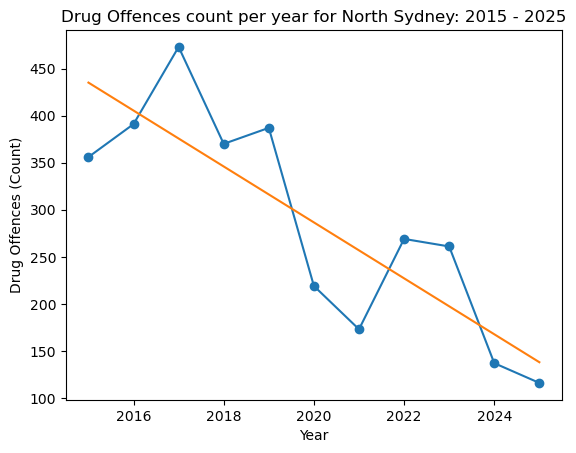

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.46
P-value: 0.159
Correlation for Northern Beaches's Drug Offences over time is not Statistically Signifigant

Pearson Correlation Coefficient: 0.88
P-value: 0.000


<Figure size 640x480 with 0 Axes>

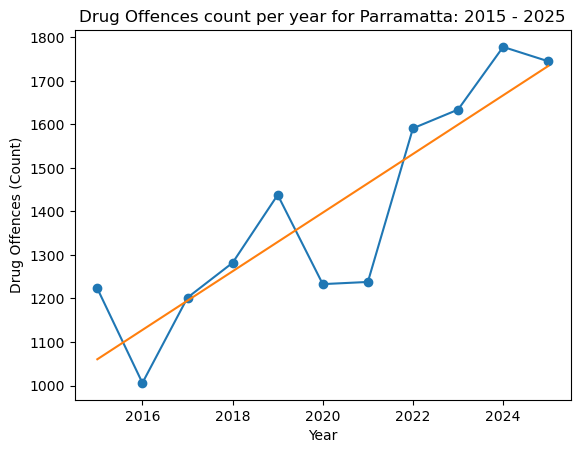

Pearson Correlation Coefficient: -0.78
P-value: 0.005


<Figure size 640x480 with 0 Axes>

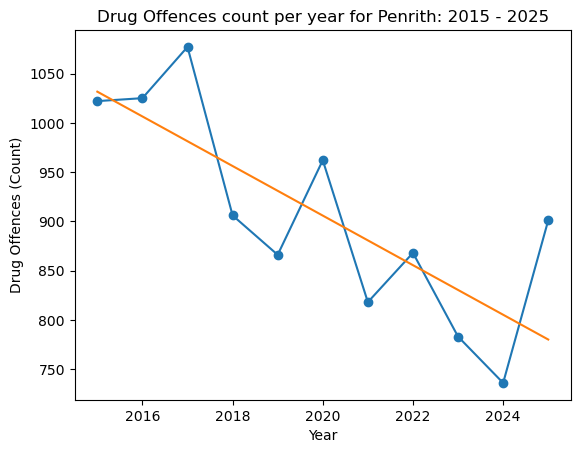

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.44
P-value: 0.176
Correlation for Randwick's Drug Offences over time is not Statistically Signifigant

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.26
P-value: 0.446
Correlation for Ryde's Drug Offences over time is not Statistically Signifigant

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: 0.18
P-value: 0.598
Correlation for Strathfield's Drug Offences over time is not Statistically Signifigant

Pearson Correlation Coefficient: -0.62
P-value: 0.043


<Figure size 640x480 with 0 Axes>

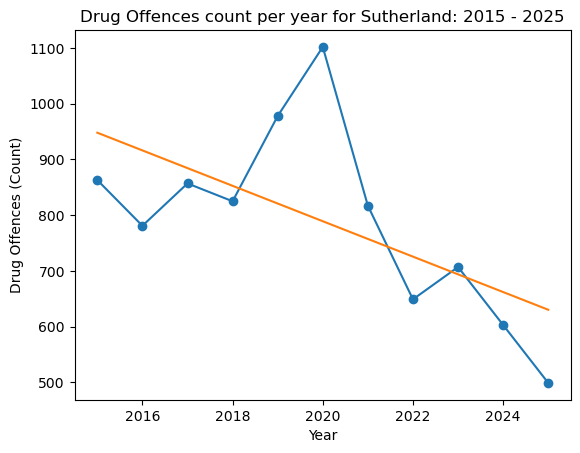

Pearson Correlation Coefficient: -0.85
P-value: 0.001


<Figure size 640x480 with 0 Axes>

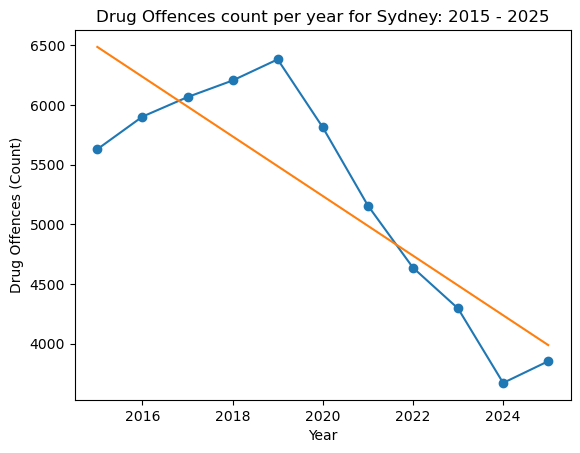

Pearson Correlation Coefficient: -0.89
P-value: 0.000


<Figure size 640x480 with 0 Axes>

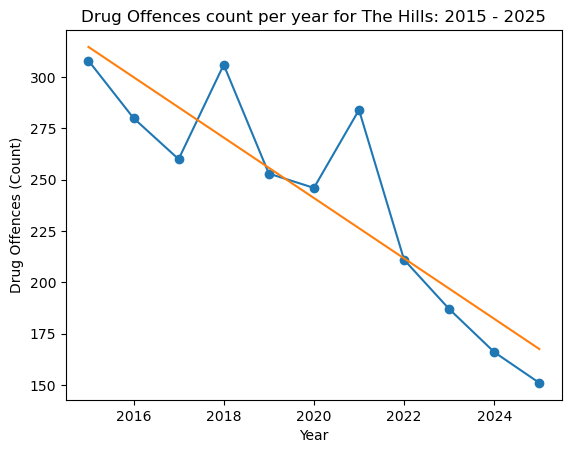

Pearson Correlation Coefficient: -0.74
P-value: 0.009


<Figure size 640x480 with 0 Axes>

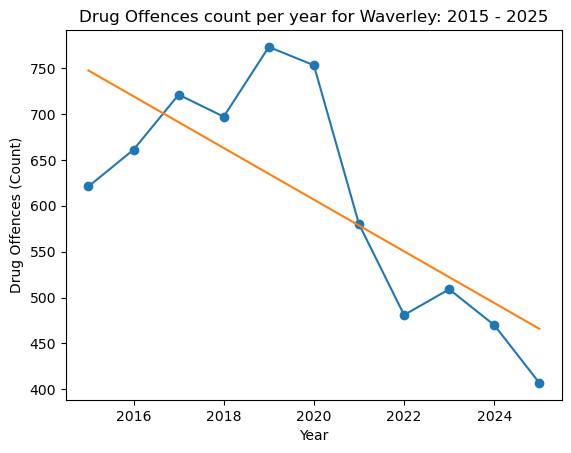

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.16
P-value: 0.632
Correlation for Willoughby's Drug Offences over time is not Statistically Signifigant

Pearson Correlation Coefficient: -0.61
P-value: 0.048


<Figure size 640x480 with 0 Axes>

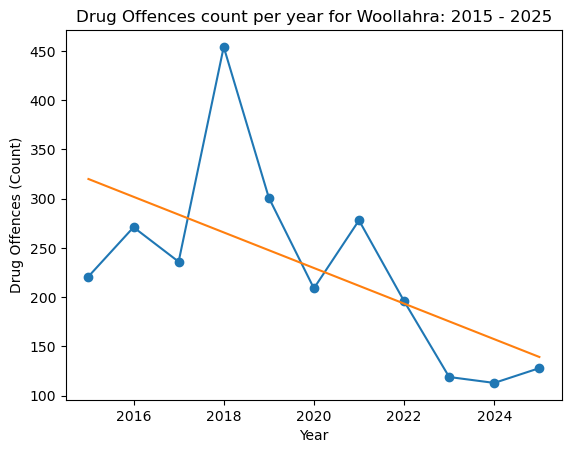

[-23.481818181818973, 42.200000000000394, 7.645454545454578, -23.6636363636367, -24.700000000000518, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -29.709090909092307, 0, 67.38181818182066, -25.15454545454623, 0, 0, 0, -31.772727272729387, -249.92727272728735, -14.718181818182256, -28.1363636363657, 0, -18.063636363637652]


<Figure size 640x480 with 0 Axes>

In [ ]:
drugsdataframe = dataframe.iloc[:, 17:28]
drugsdataframe.insert(0, "LGA_NAME25", dataframe["LGA_NAME25"])

time = [2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]

mlistdrugs = []

for i, row in drugsdataframe.iterrows():
    
    LGA = row["LGA_NAME25"]
    y = row.iloc[1:].to_numpy(dtype=float)
    
    p,r = correlation(time,y)
    
    if p > 0.05:
        print(f"Correlation for {LGA}'s Drug Offences over time is not Statistically Signifigant\n")
        m = 0 
    else:
        m = float(graphtime(time, y, "Drug Offences", LGA))
        
    mlistdrugs.append(m)

